# Fitting distribution and goodness-of-fit

## Importing modules

In [111]:
# Import modules
import pandas as pd
import matplotlib.pyplot as plt
from fitter import Fitter
from scipy import stats

## Loading data


In [112]:
#Loading data
dataset = pd.read_excel("../MillerPainTreatmentCenterData.xlsx")

dataset

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Record,Registration,Vitals,Physicians Assistant,Check Out
0,1,9.0,3.0,15.0,1.0
1,2,4.0,2.0,26.0,5.0
2,3,9.0,3.0,47.0,4.0
3,4,8.0,3.0,24.0,10.0
4,5,4.0,4.0,56.0,9.0
...,...,...,...,...,...
94,95,1.0,3.0,34.0,5.0
95,96,2.0,3.0,16.0,6.0
96,97,4.0,3.0,7.0,4.0
97,98,6.0,3.0,21.0,6.0


In [113]:
#To make histogram of resident and patient times
Exhibit6 = pd.read_excel("../MillerPainTreatmentCenterData.xlsx", sheet_name = "Exhibit6")

Exhibit6

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,Record,Resident Review,Resident & Patient,Teach,Resident & Attending
0,1,1.0,27.0,3.0,14.0
1,2,5.0,17.0,8.0,5.0
2,3,7.0,9.0,3.0,7.0
3,4,0.0,17.0,2.0,1.0
4,5,6.0,27.0,7.0,9.0
...,...,...,...,...,...
86,87,35.0,23.0,4.0,20.0
87,88,4.0,8.0,NaN,20.0
88,89,3.0,13.0,NaN,20.0
89,90,3.0,29.0,NaN,6.0


## Fit appropriate distributions

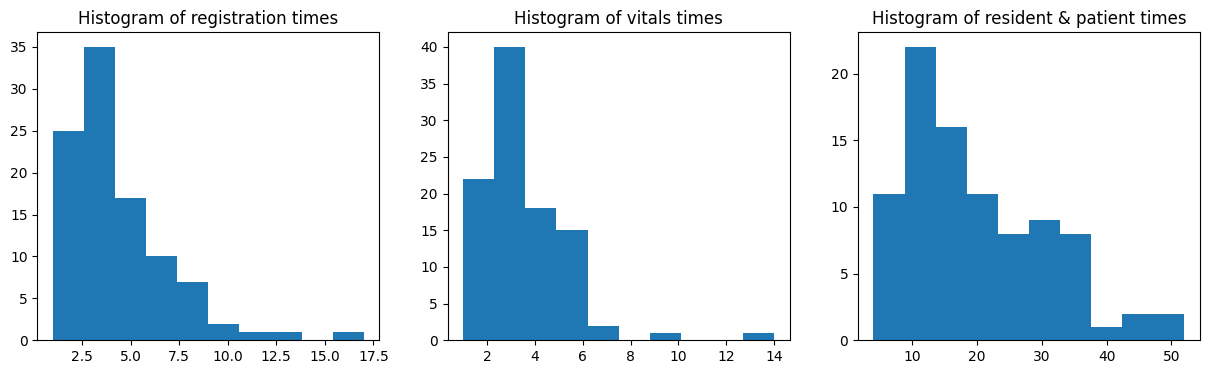

In [114]:
#Histogram of selected variables
fig, ax = plt.subplots(1, 3, figsize = (15, 4))

ax[0].hist(dataset["Registration"])
ax[0].set_title("Histogram of registration times")

ax[1].hist(dataset["Vitals"])
ax[1].set_title("Histogram of vitals times")

ax[2].hist(Exhibit6["Resident & Patient"])
ax[2].set_title("Histogram of resident & patient times")

plt.show()

By the shape of the histograms, and as our data contains time (minutes), we can assume that distributions such as the ones below could suit the process.

2026-04-12 01:05:46.864 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted gamma: error=4.144972, AIC=440.11, KS=0.1235
2026-04-12 01:05:46.877 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted beta: error=4.147858, AIC=442.09, KS=0.1263


        sumsquare_error         aic         bic     kl_div  ks_statistic  \
gamma          4.144972  440.109034  447.894394  16.626315      0.123484   
erlang         4.144972  440.109034  447.894394  16.626311      0.123479   
beta           4.147858  442.087527  452.468006  16.613721      0.126256   
expon          4.234585  440.386615  445.576855  16.403733      0.198663   
norm           4.235021  479.434873  484.625113  16.454896      0.179208   

        ks_pvalue  
gamma    0.089616  
erlang   0.089640  
beta     0.077945  
expon    0.000671  
norm     0.002974  


2026-04-12 01:05:47.807 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted norm: error=4.235021, AIC=479.43, KS=0.1792
2026-04-12 01:05:47.807 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted expon: error=4.234585, AIC=440.39, KS=0.1987
2026-04-12 01:05:47.810 | INFO     | fitter.fitter:_fit_single_distribution:408 - Fitted erlang: error=4.144972, AIC=440.11, KS=0.1235


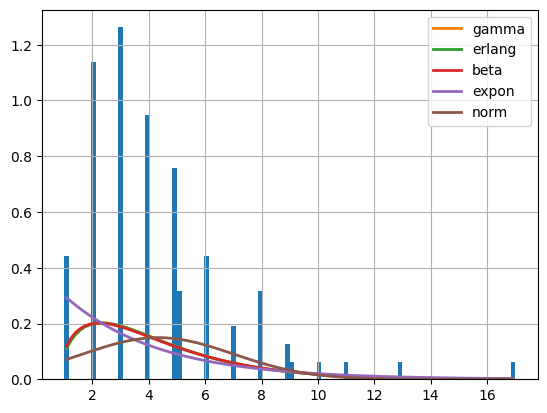

In [115]:
#Fitting
fitDist = Fitter(dataset["Registration"], distributions =['norm', 'expon', 'gamma', 'beta', 'erlang'])
fitDist.fit()
print(fitDist.summary())

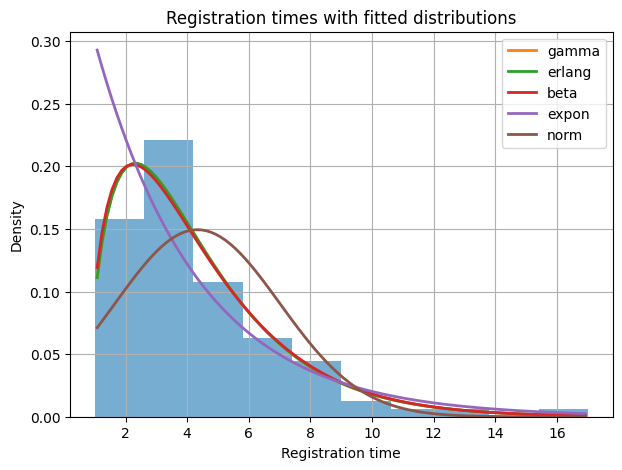

In [ ]:
#Distributions on histogram of registration time
plt.figure(figsize = (7, 5))
plt.hist(dataset["Registration"], bins = 10, density = True, alpha = 0.6)
fitDist.plot_pdf()

plt.title("Registration times with fitted distributions")
plt.xlabel("Registration time")
plt.ylabel("Density")
plt.show()

## Goodness-of-fit test

In [ ]:
#Kolmogorov-Smirnov test
shape, loc, scale = fitDist.fitted_param["gamma"]

ks_stat, p_value = stats.kstest(dataset["Registration"], "gamma", args = (shape, loc, scale))

print(f"KS Statistic: {ks_stat:.4f}")
print(f"P-value: {p_value:.4f}")

KS Statistic: 0.1235
P-value: 0.0896


In [ ]:
# Print the parameters
print("Exponential parameters")
loc, scale = fitDist.fitted_param['expon']
print(f"location: {loc}, scale: {scale:.4f}","\n")

print("Erlang parameters")
shp1, loc, scale = fitDist.fitted_param['erlang']
print(f"shape: {shp1:.4f}, location: {loc:.4f}, scale: {scale:.4f}","\n")

shp1, shp2, loc, scale = fitDist.fitted_param['beta']
print("Beta parameters")
print(f"shape 1: {shp1:.4f}, shape 2: {shp2:.4f}, location: {loc:.4f}, scale: {scale:.4f}","\n")

shp1, loc, scale = fitDist.fitted_param['gamma']
print("Gamma parameters")
print(f"shape: {shp1:.4f}, location: {loc:.4f}, scale: {scale:.4f}","\n")

loc, scale = fitDist.fitted_param['norm']
print("Normal parameters")
print(f"location: {loc:.4f}, scale: {scale:.4f}","\n")

Exponential parameters
location: 0.9999999999999964, scale: 3.3333 

Erlang parameters
shape: 1.7812, location: 0.7489, scale: 2.0124 

Beta parameters
shape 1: 1.6377, shape 2: 45.2292, location: 0.7963, scale: 101.2155 

Gamma parameters
shape: 1.7812, location: 0.7489, scale: 2.0124 

Normal parameters
location: 4.3333, scale: 2.6705 

